In [1]:
import os, numpy as np, pandas as pd
import lightgbm as lgb
import torch, torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from pandas.tseries.holiday import USFederalHolidayCalendar

POLICY_DATE = pd.Timestamp("2025-01-05")
L, H        = 168, 24
TARGETS     = ["n_trips", "speed_median_mph"]
GROUP       = "treated"
TEST_DAYS   = 90
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def resolve_data_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        return "/content/drive/MyDrive/nyc-crz-counterfactual"
    except Exception:
        return "./nyc-crz-counterfactual"

DATA_DIR  = resolve_data_dir()
FEAT_PATH = os.path.join(DATA_DIR, "crz_features_3grp.parquet")
SKILL_OUT = os.path.join(DATA_DIR, "forecast_skill_per_horizon.csv")

feat = pd.read_parquet(FEAT_PATH); feat["datetime"]=pd.to_datetime(feat["datetime"])
print("Device:", DEVICE, "| L", L, "H", H, "| target series:", GROUP)

Mounted at /content/drive
Device: cuda | L 168 H 24 | target series: treated


In [2]:
def calendar_block(idx):
    hr, dow, doy = idx.hour.to_numpy(), idx.dayofweek.to_numpy(), idx.dayofyear.to_numpy()
    hols = USFederalHolidayCalendar().holidays(start=idx.min(), end=idx.max())
    cal = np.column_stack([
        np.sin(2*np.pi*hr/24),  np.cos(2*np.pi*hr/24),
        np.sin(2*np.pi*dow/7),  np.cos(2*np.pi*dow/7),
        np.sin(2*np.pi*doy/366),np.cos(2*np.pi*doy/366),
        (dow>=5).astype(float),  idx.normalize().isin(hols).astype(float)]).astype("float32")
    return cal  # (T, 8)

def make_windows(y, cal, L, H):
    """y:(T,) cal:(T,8). Returns Xseq(N,L,9), Xfut(N,H,8), Y(N,H), origin_pos(N,)."""
    seq = np.concatenate([y[:,None], cal], axis=1).astype("float32")    # (T,9)
    sw  = sliding_window_view(seq, L, axis=0).transpose(0,2,1)          # (T-L+1, L, 9)
    T = len(y); n = T - L - H + 1                                       # valid origins
    Xseq = sw[:n]                                                       # origin pos o = L-1+w
    o = np.arange(n) + (L-1)
    yfut_w = sliding_window_view(y, H, axis=0)                          # (T-H+1, H)
    cfut_w = sliding_window_view(cal, H, axis=0).transpose(0,2,1)       # (T-H+1, H, 8)
    Y    = yfut_w[o+1]                                                  # targets o+1..o+H
    Xfut = cfut_w[o+1]
    return Xseq, Xfut.astype("float32"), Y.astype("float32"), o

def prep_series(feat, group, target):
    s = (feat[feat.group==group].set_index("datetime")[target].sort_index())
    s = s[s.index < POLICY_DATE]                                       # pre-period only
    full = pd.date_range(s.index.min(), s.index.max(), freq="h")
    s = s.reindex(full).interpolate("linear").bfill().ffill()
    return s.index, s.to_numpy().astype("float32")

In [3]:
LAGS = [1,2,3,24,25,168]
def lgb_table(idx, y, cal, origins, H):
    """Per (origin, horizon) rows: lags & rolling at origin + target-hour calendar + horizon."""
    roll24  = pd.Series(y).rolling(24,  min_periods=1).mean().to_numpy()
    roll168 = pd.Series(y).rolling(168, min_periods=1).mean().to_numpy()
    base = {f"lag{k}": y[origins-k+1] for k in LAGS}        # lag1=y[origin], etc.
    base["roll24"], base["roll168"] = roll24[origins], roll168[origins]
    rows=[]
    for h in range(1, H+1):
        tt = origins + h
        tti = pd.DatetimeIndex(idx[tt])
        d = {k:v.copy() for k,v in base.items()}
        d["hour"]=np.asarray(tti.hour); d["dow"]=np.asarray(tti.dayofweek)
        d["month"]=np.asarray(tti.month); d["doy"]=np.asarray(tti.dayofyear)
        d["is_weekend"]=np.asarray((tti.dayofweek>=5).astype(int))
        d["horizon"]=h
        d["_y"]=y[tt]; d["_origin"]=origins
        rows.append(pd.DataFrame(d))
    return pd.concat(rows, ignore_index=True)

LGB_PARAMS = dict(objective="regression", n_estimators=400, learning_rate=0.05,
                  num_leaves=63, min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, verbosity=-1)

def run_lgbm(idx, y, cal, tr_o, te_o, H):
    tr = lgb_table(idx, y, cal, tr_o, H); te = lgb_table(idx, y, cal, te_o, H)
    Xcols = [c for c in tr.columns if not c.startswith("_")]
    m = lgb.LGBMRegressor(**LGB_PARAMS).fit(tr[Xcols], tr["_y"])
    te = te.assign(pred=m.predict(te[Xcols]))
    return te[["horizon","_y","pred"]].rename(columns={"_y":"y"})

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_seq=9, n_cal=8, H=24, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_seq, hidden, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden + n_cal*H, 128), nn.ReLU(),
                                  nn.Dropout(0.1), nn.Linear(128, H))
    def forward(self, xseq, xfut):
        _, (hn, _) = self.lstm(xseq)
        z = torch.cat([hn[-1], xfut.reshape(xfut.size(0), -1)], dim=1)
        return self.head(z)

def run_lstm(Xseq, Xfut, Y, tr, va, te, ymu, ysd, H, epochs=25, device=DEVICE):
    def t(a): return torch.tensor(a, dtype=torch.float32, device=device)
    model = LSTMForecaster(n_seq=Xseq.shape[2], n_cal=Xfut.shape[2], H=H).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); lossf = nn.MSELoss()
    Xs,Xf,Yt = t(Xseq), t(Xfut), t((Y-ymu)/ysd)
    best=np.inf; best_state=None; patience=4; bad=0; bs=256
    for ep in range(epochs):
        model.train(); perm=np.random.permutation(tr)
        for i in range(0,len(perm),bs):
            b=perm[i:i+bs]; opt.zero_grad()
            loss=lossf(model(Xs[b],Xf[b]), Yt[b]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl=lossf(model(Xs[va],Xf[va]), Yt[va]).item()
        if vl<best-1e-5: best=vl; best_state={k:v.clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=patience: break
    if best_state: model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred=(model(Xs[te],Xf[te]).cpu().numpy()*ysd)+ymu
    return pred  # (n_te, H), original units

In [5]:
def per_horizon_rmse(y, p):   # y,p: (n,H)
    return np.sqrt(np.mean((y-p)**2, axis=0))

results={}
for target in TARGETS:
    idx, y = prep_series(feat, GROUP, target)
    cal = calendar_block(idx)
    Xseq, Xfut, Y, origin_pos = make_windows(y, cal, L, H)
    o_time = idx[origin_pos]
    test_start = POLICY_DATE - pd.Timedelta(days=TEST_DAYS)
    is_te = (o_time >= test_start)
    is_tr = ~is_te
    tr_idx = np.where(is_tr)[0]; te_idx = np.where(is_te)[0]
    # small val split off the tail of train for LSTM early stopping
    n_va = max(1, int(0.1*len(tr_idx))); va_idx = tr_idx[-n_va:]; tr_core = tr_idx[:-n_va]
    ymu, ysd = y[origin_pos[tr_idx]].mean(), y[origin_pos[tr_idx]].std()+1e-8

    # seasonal-naive: y[t0+h] ~ y[t0+h-168]
    naive = np.column_stack([y[origin_pos[te_idx]+h-168] for h in range(1,H+1)])
    # lgbm
    lg = run_lgbm(idx, y, cal, origin_pos[tr_idx], origin_pos[te_idx], H)
    lg_mat  = (lg.assign(row=lg.groupby("horizon").cumcount())
                 .pivot(index="row", columns="horizon", values="pred").to_numpy())
    lg_y    = (lg.assign(row=lg.groupby("horizon").cumcount())
                 .pivot(index="row", columns="horizon", values="y").to_numpy())
    # lstm
    lstm_pred = run_lstm(Xseq, Xfut, Y, tr_core, va_idx, te_idx, ymu, ysd, H)
    Yte = Y[te_idx]
    results[target] = {
        "horizon": np.arange(1,H+1),
        "naive": per_horizon_rmse(Yte, naive),
        "lightgbm": per_horizon_rmse(lg_y, lg_mat),
        "lstm": per_horizon_rmse(Yte, lstm_pred)}
    print(f"[{target}] test origins={len(te_idx)}  "
          f"overall RMSE  naive={results[target]['naive'].mean():.3f}  "
          f"lgbm={results[target]['lightgbm'].mean():.3f}  "
          f"lstm={results[target]['lstm'].mean():.3f}")

[n_trips] test origins=2136  overall RMSE  naive=1021.564  lgbm=586.468  lstm=745.988
[speed_median_mph] test origins=2136  overall RMSE  naive=1.070  lgbm=0.891  lstm=0.835


Mean RMSE over all horizons:
                        naive  lightgbm        lstm  lstm_vs_lgbm_pct
target                                                               
n_trips           1021.564026   586.468  745.987976           -27.200
speed_median_mph     1.070000     0.891    0.835000             6.307


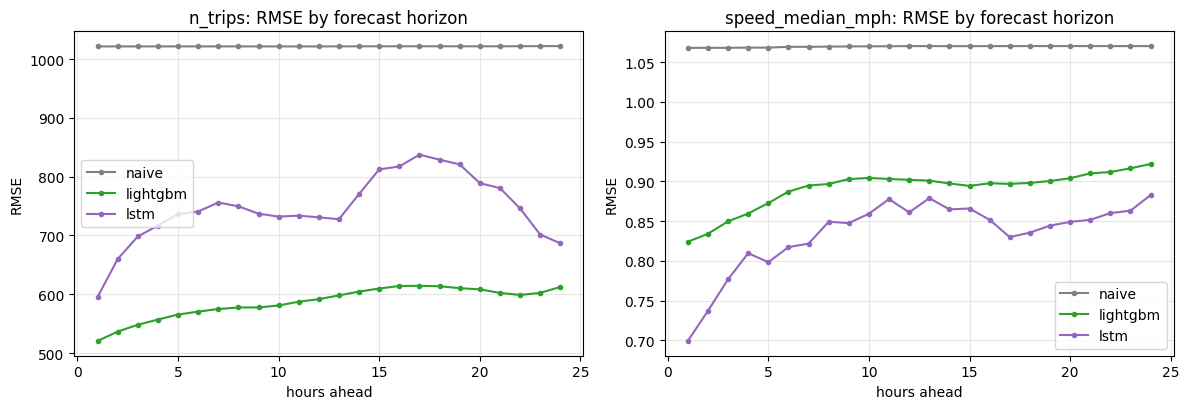


Saved: /content/drive/MyDrive/nyc-crz-counterfactual/forecast_skill_per_horizon.csv


In [6]:
import matplotlib.pyplot as plt
rows=[]
for target,r in results.items():
    for i,h in enumerate(r["horizon"]):
        rows.append({"target":target,"horizon":int(h),
                     "naive":r["naive"][i],"lightgbm":r["lightgbm"][i],"lstm":r["lstm"][i]})
skill=pd.DataFrame(rows); skill.to_csv(SKILL_OUT, index=False)

summary=(skill.groupby("target")[["naive","lightgbm","lstm"]].mean()
              .assign(lstm_vs_lgbm_pct=lambda d:(1-d["lstm"]/d["lightgbm"])*100))
print("Mean RMSE over all horizons:"); print(summary.round(3).to_string())

fig,axes=plt.subplots(1,len(TARGETS),figsize=(6*len(TARGETS),4.2))
axes=np.atleast_1d(axes)
for ax,target in zip(axes,TARGETS):
    r=results[target]
    for name,c in [("naive","gray"),("lightgbm","tab:green"),("lstm","tab:purple")]:
        ax.plot(r["horizon"], r[name], marker=".", color=c, label=name)
    ax.set_title(f"{target}: RMSE by forecast horizon"); ax.set_xlabel("hours ahead")
    ax.set_ylabel("RMSE"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()
print("\nSaved:", SKILL_OUT)